## 🔍 Quick Navigation Helper

Run this cell to print the current cell structure and find what you need!


In [2]:
import sys
import os
import pickle
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Add the parent directory to path to import easy_tpp
sys.path.insert(0, os.path.abspath('..'))

from easy_tpp.config_factory import Config
from easy_tpp.runner import Runner

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize global training history dictionary
training_history = {}

print("✓ Imports successful")
print("✓ Training history initialized")


✓ Imports successful
✓ Training history initialized


## 1. Configuration Setup

Define the models and datasets you want to compare.


In [3]:
# Models to evaluate on StackOverflow
# MODELS = ['NHP', 'RMTPP', 'THP', 'SAHP']
MODELS = ['THP']

# Training configuration
BATCH_SIZE = 256
MAX_EPOCHS = 10
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
GPU = -1  # -1 for CPU, 0 for GPU

# Results directory
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"✓ Models to train: {MODELS}")
print(f"✓ Training: {MAX_EPOCHS} epochs, batch {BATCH_SIZE}")
print(f"✓ Dataset: StackOverflow (10,000 sequences)")
print(f"✓ Results: {RESULTS_DIR}/")
print(f"\n💡 Smart caching: Files won't re-download if already present")


✓ Models to train: ['THP']
✓ Training: 10 epochs, batch 256
✓ Dataset: StackOverflow (10,000 sequences)
✓ Results: ./results/

💡 Smart caching: Files won't re-download if already present


## 3.5 Setup Training History Tracking

📍 **[CELL 9]** - This cell defines the `train_with_history()` function

Define the function to track learning curves during training.


In [5]:
def train_with_history(model_runner, model_name):
    """
    Train model and track metrics at each epoch.
    This function replaces the standard model_runner.run() to capture learning curves.
    """
    from easy_tpp.utils import RunnerPhase
    
    # Get data loaders
    train_loader = model_runner._data_loader.train_loader()
    valid_loader = model_runner._data_loader.valid_loader()
    test_loader = model_runner._data_loader.test_loader()
    
    max_epochs = model_runner.runner_config.trainer_config.max_epoch
    
    # Initialize history
    history = {
        'train_loglike': [],
        'valid_loglike': [],
        'test_loglike': [],
        'epochs': []
    }
    
    print(f"Training {model_name} with history tracking...")
    
    # Train epoch by epoch
    for epoch in range(max_epochs):
        # Train
        train_metrics = model_runner.run_one_epoch(train_loader, RunnerPhase.TRAIN)
        history['train_loglike'].append(train_metrics['loglike'])
        
        # Validate
        valid_metrics = model_runner.run_one_epoch(valid_loader, RunnerPhase.VALIDATE)
        history['valid_loglike'].append(valid_metrics['loglike'])
        
        # Test
        test_metrics = model_runner.run_one_epoch(test_loader, RunnerPhase.VALIDATE)
        history['test_loglike'].append(test_metrics['loglike'])
        
        history['epochs'].append(epoch)
        
        # Update best model
        updated = model_runner.metrics_tracker.update_best("loglike", valid_metrics['loglike'], epoch)
        
        if updated:
            model_runner.model_wrapper.save(model_runner.runner_config.base_config.specs['saved_model_dir'])
        
        # Print progress
        print(f"  Epoch {epoch}/{max_epochs-1} - "
              f"train: {train_metrics['loglike']:.4f}, "
              f"valid: {valid_metrics['loglike']:.4f}, "
              f"test: {test_metrics['loglike']:.4f}")
    
    model_runner.model_wrapper.close_summary()
    
    # Store in global history
    global training_history
    training_history[model_name] = history
    
    print(f"✓ Training complete. History saved to training_history['{model_name}']")
    
    return test_metrics

print("✓ Training history tracking function defined")


✓ Training history tracking function defined


## 8. Use Real StackOverflow Dataset from SNAP

Let's download and use the real **StackOverflow temporal network** from [SNAP Stanford](https://snap.stanford.edu/data/sx-stackoverflow.html).

This dataset contains temporal interactions:
- User u answered user v's question at time t
- User u commented on user v's question at time t  
- User u commented on user v's answer at time t

We'll convert this raw temporal network data into the EasyTPP format.


In [6]:
import urllib.request
import gzip
import shutil
from collections import defaultdict
from datetime import datetime

def download_stackoverflow_snap():
    """Download StackOverflow dataset from SNAP Stanford."""
    # Create directory
    raw_dir = './data/stackoverflow_raw'
    os.makedirs(raw_dir, exist_ok=True)
    
    # File paths
    url = 'http://snap.stanford.edu/data/sx-stackoverflow-a2q.txt.gz'
    output_file = f'{raw_dir}/sx-stackoverflow-a2q.txt.gz'
    txt_file = output_file.replace('.gz', '')
    
    # Check if already downloaded and extracted
    if os.path.exists(txt_file):
        file_size = os.path.getsize(txt_file) / (1024 * 1024)  # MB
        print(f"\n{'='*60}")
        print("Dataset Already Downloaded")
        print(f"{'='*60}\n")
        print(f"✓ Found existing file: {txt_file}")
        print(f"✓ File size: {file_size:.1f} MB")
        print(f"\n💡 Skipping download (file already exists)")
        print(f"   To re-download, delete: {txt_file}")
        return txt_file
    
    # If not found, download it
    print(f"\n{'='*60}")
    print("Downloading StackOverflow dataset from SNAP Stanford")
    print(f"{'='*60}\n")
    
    print(f"Downloading from: {url}")
    print(f"This may take a few minutes (~250 MB)...")
    
    try:
        # Download the file
        urllib.request.urlretrieve(url, output_file)
        print(f"✓ Downloaded to: {output_file}")
        
        # Extract the gz file
        print(f"\nExtracting...")
        with gzip.open(output_file, 'rb') as f_in:
            with open(txt_file, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        
        print(f"✓ Extracted to: {txt_file}")
        
        # Check file size
        file_size = os.path.getsize(txt_file) / (1024 * 1024)  # MB
        print(f"\nFile size: {file_size:.1f} MB")
        
        return txt_file
        
    except Exception as e:
        print(f"✗ Error downloading: {str(e)}")
        print(f"\nManual download:")
        print(f"  1. Visit: https://snap.stanford.edu/data/sx-stackoverflow.html")
        print(f"  2. Download sx-stackoverflow-a2q.txt.gz")
        print(f"  3. Extract and place in: {raw_dir}/")
        return None

# Download the dataset (skips if already downloaded)
stackoverflow_file = download_stackoverflow_snap()



Dataset Already Downloaded

✓ Found existing file: ./data/stackoverflow_raw/sx-stackoverflow-a2q.txt
✓ File size: 437.0 MB

💡 Skipping download (file already exists)
   To re-download, delete: ./data/stackoverflow_raw/sx-stackoverflow-a2q.txt


In [7]:
def convert_snap_to_easytpp(raw_file, output_dir='./data/stackoverflow', 
                             min_events=10, max_events=200, num_sequences=10000):
    """
    Convert SNAP StackOverflow format to EasyTPP format.
    
    SNAP format: SRC DST UNIXTS (source user, destination user, unix timestamp)
    EasyTPP format: List of sequences, each sequence is a list of events with:
        - idx_event: event index
        - type_event: event type (we'll use a simple categorization)
        - time_since_start: time from sequence start (in days)
        - time_since_last_event: time since previous event (in days)
    """
    if raw_file is None:
        print("❌ No file to process. Download first.")
        return None
    
    # Check if already converted
    train_file = f'{output_dir}/train.pkl'
    if os.path.exists(train_file):
        print(f"\n{'='*60}")
        print("Dataset Already Converted")
        print(f"{'='*60}\n")
        print(f"✓ Found existing files in: {output_dir}/")
        print(f"  - train.pkl")
        print(f"  - dev.pkl")
        print(f"  - test.pkl")
        print(f"\n💡 Skipping conversion (files already exist)")
        print(f"   To reconvert, delete the directory: {output_dir}/")
        
        # Read dim_process from existing file
        with open(train_file, 'rb') as f:
            data = pickle.load(f)
            dim_process = data.get('dim_process', 10)
        
        print(f"✓ Event types: {dim_process}")
        return dim_process
    
    print(f"\n{'='*60}")
    print("Converting SNAP format to EasyTPP format")
    print(f"{'='*60}\n")
    
    # Read the raw data
    print(f"Reading data from: {raw_file}")
    user_events = defaultdict(list)
    
    with open(raw_file, 'r') as f:
        for i, line in enumerate(f):
            if i % 1000000 == 0 and i > 0:
                print(f"  Processed {i:,} edges...")
            
            parts = line.strip().split()
            if len(parts) == 3:
                src, dst, timestamp = parts
                user_events[src].append({
                    'dst': dst,
                    'timestamp': int(timestamp)
                })
    
    print(f"\n✓ Loaded {i+1:,} edges from {len(user_events):,} users")
    
    # Filter users with sufficient events
    filtered_users = {
        user: events for user, events in user_events.items()
        if min_events <= len(events) <= max_events
    }
    
    print(f"✓ Found {len(filtered_users):,} users with {min_events}-{max_events} events")
    
    # Sample users
    sampled_users = list(filtered_users.keys())[:num_sequences]
    print(f"✓ Sampling {len(sampled_users)} users")
    
    # Convert to EasyTPP format
    sequences = []
    num_event_types = 10  # We'll create 10 event types based on target user hash
    
    for user in sampled_users:
        events = sorted(filtered_users[user], key=lambda x: x['timestamp'])
        
        # Get start time
        start_time = events[0]['timestamp']
        
        # Convert to EasyTPP format
        sequence = []
        prev_time = start_time
        
        for idx, event in enumerate(events, 1):
            time_since_start = (event['timestamp'] - start_time) / 86400.0  # Convert to days
            time_since_last = (event['timestamp'] - prev_time) / 86400.0
            
            # Assign event type based on target user (simple hash)
            event_type = int(event['dst']) % num_event_types
            
            sequence.append({
                'idx_event': idx,
                'type_event': event_type,
                'time_since_start': time_since_start,
                'time_since_last_event': time_since_last
            })
            
            prev_time = event['timestamp']
        
        sequences.append(sequence)
    
    # Split into train/dev/test (70/10/20)
    n = len(sequences)
    n_train = int(0.7 * n)
    n_dev = int(0.1 * n)
    
    train_data = sequences[:n_train]
    dev_data = sequences[n_train:n_train+n_dev]
    test_data = sequences[n_train+n_dev:]
    
    print(f"\n✓ Created sequences:")
    print(f"  Train: {len(train_data)}")
    print(f"  Dev: {len(dev_data)}")
    print(f"  Test: {len(test_data)}")
    
    # Save to pickle files
    os.makedirs(output_dir, exist_ok=True)
    
    train_dict = {'train': train_data, 'dim_process': num_event_types}
    dev_dict = {'dev': dev_data, 'dim_process': num_event_types}
    test_dict = {'test': test_data, 'dim_process': num_event_types}
    
    with open(f'{output_dir}/train.pkl', 'wb') as f:
        pickle.dump(train_dict, f)
    with open(f'{output_dir}/dev.pkl', 'wb') as f:
        pickle.dump(dev_dict, f)
    with open(f'{output_dir}/test.pkl', 'wb') as f:
        pickle.dump(test_dict, f)
    
    print(f"\n✓ Saved EasyTPP format to: {output_dir}/")
    
    # Show sample
    print(f"\nSample sequence (first 3 events):")
    for i, event in enumerate(train_data[0][:3]):
        print(f"  Event {i}: {event}")
    
    return num_event_types

# Convert the dataset
stackoverflow_dim_process = convert_snap_to_easytpp(stackoverflow_file)



Dataset Already Converted

✓ Found existing files in: ./data/stackoverflow/
  - train.pkl
  - dev.pkl
  - test.pkl

💡 Skipping conversion (files already exist)
   To reconvert, delete the directory: ./data/stackoverflow/
✓ Event types: 10


In [19]:
# Train models on StackOverflow dataset
def train_on_stackoverflow(dim_process, models_to_train):
    """Train models on StackOverflow dataset."""
    
    if dim_process is None:
        print("❌ Dataset not available. Please process it first.")
        return {}
    
    dataset_name = 'stackoverflow'
    
    print(f"\n{'='*60}")
    print(f"Training models on StackOverflow dataset")
    print(f"{'='*60}\n")
    
    # Create configuration function
    def create_model_config_stackoverflow(model_name, dim_process, stage='train'):
        """Create configuration dictionary for StackOverflow dataset."""
        
        config = {
            'pipeline_config_id': 'runner_config',
            'data': {
                dataset_name: {
                    'data_format': 'pkl',
                    'train_dir': f'./data/{dataset_name}/train.pkl',
                    'valid_dir': f'./data/{dataset_name}/dev.pkl',
                    'test_dir': f'./data/{dataset_name}/test.pkl',
                    'data_specs': {
                        'num_event_types': dim_process,
                        'pad_token_id': dim_process,
                        'padding_side': 'right',
                        'truncation_side': 'right',
                        'max_len': 200  # StackOverflow sequences can be longer
                    }
                }
            },
            f'{model_name}_{stage}': {
                'base_config': {
                    'stage': stage,
                    'backend': 'torch',
                    'dataset_id': dataset_name,
                    'runner_id': 'std_tpp',
                    'model_id': model_name,
                    'base_dir': f'./checkpoints_{dataset_name}/'
                },
                'model_config': {
                    'hidden_size': HIDDEN_SIZE,
                    'time_emb_size': 16,
                    'num_layers': 2,
                    'num_heads': 2,
                    'dropout': 0.1,
                    'use_ln': False,
                    'thinning_params': {
                        'num_seq': 10,
                        'num_sample': 1,
                        'num_exp': 500,
                        'look_ahead_time': 10,
                        'patience_counter': 5,
                        'over_sample_rate': 5,
                        'num_samples_boundary': 5,
                        'dtime_max': 10  # Increased for longer time spans
                    }
                },
                'trainer_config': {
                    'seed': 2019,
                    'gpu': GPU,
                    'batch_size': BATCH_SIZE,
                    'max_epoch': MAX_EPOCHS,
                    'optimizer': 'adam',
                    'learning_rate': LEARNING_RATE,
                    'valid_freq': 1,
                    'use_tfb': False,
                    'metrics': ['acc', 'rmse']
                }
            }
        }
        
        return config
    
    results_stackoverflow = {}
    
    for model_name in models_to_train:
        try:
            print(f"\n{'='*60}")
            print(f"Training {model_name} on StackOverflow")
            print(f"{'='*60}\n")
            
            # Create config
            config_dict = create_model_config_stackoverflow(model_name, dim_process, stage='train')
            
            # Save config
            config_path = f'{RESULTS_DIR}/{dataset_name}_{model_name}_config.yaml'
            with open(config_path, 'w') as f:
                yaml.dump(config_dict, f, default_flow_style=False)
            
            print(f"Configuration saved to: {config_path}")
            
            # Load config and create runner
            config = Config.build_from_yaml_file(config_path, experiment_id=f'{model_name}_train')
            model_runner = Runner.build_from_config(config)
            
            # Train with history tracking
            print("Training started with history tracking...")
            test_metrics = train_with_history(model_runner, f'{dataset_name}_{model_name}')
            
            print(f"\n{model_name} Test Results on StackOverflow:")
            for metric, value in test_metrics.items():
                print(f"  {metric}: {value:.4f}")
            
            results_stackoverflow[model_name] = test_metrics
            print(f"\n✓ {model_name} completed successfully!")
            
        except Exception as e:
            print(f"\n✗ Error training {model_name}: {str(e)}")
            import traceback
            traceback.print_exc()
            results_stackoverflow[model_name] = None
        
        print("\n")
    
    return results_stackoverflow

# Train all 4 models on StackOverflow: NHP, RMTPP, THP, SAHP
if stackoverflow_dim_process is not None:
    print("🚀 Training 4 models: NHP, RMTPP, THP, SAHP")
    print(f"   Dataset: StackOverflow (5000 sequences)")
    print(f"   Config: {MAX_EPOCHS} epochs, batch size {BATCH_SIZE}\n")
    
    stackoverflow_results = train_on_stackoverflow(
        stackoverflow_dim_process, 
        models_to_train=['NHP', 'THP']
    )
else:
    print("⚠ Dataset not ready. Run Cell 15 (download) and Cell 16 (convert) first!")


🚀 Training 4 models: NHP, RMTPP, THP, SAHP
   Dataset: StackOverflow (5000 sequences)
   Config: 10 epochs, batch size 256


Training models on StackOverflow dataset


Training NHP on StackOverflow

Configuration saved to: ./results/stackoverflow_NHP_config.yaml
2025-11-14 15:59:23,780 - config.py[pid:44912;line:34:build_from_yaml_file] - CRITICAL: Load pipeline config class RunnerConfig
2025-11-14 15:59:23,791 - runner_config.py[pid:44912;line:140:update_config] - CRITICAL: train model NHP using CPU with torch backend
2025-11-14 15:59:23,806 - runner_config.py[pid:44912;line:35:__init__] - INFO: Save the config to ./checkpoints_stackoverflow/44912_140704456446144_251114-155923/NHP_train_output.yaml
2025-11-14 15:59:23,810 - base_runner.py[pid:44912;line:176:save_log] - INFO: Save the log to ./checkpoints_stackoverflow/44912_140704456446144_251114-155923/log
35.39113339110108 114.9178303425722
min_dt: 5.787037037037037e-05
max_dt: 2613.951747685185
2025-11-14 15:59:25,159 - tpp_runner.

In [20]:
# Check training history status
print(f"Current training_history keys: {list(training_history.keys())}")
if training_history:
    print(f"✓ Training history contains {len(training_history)} model(s)")
    for model_name in training_history.keys():
        print(f"  - {model_name}")
else:
    print("⚠ Training history is empty. Train models first using Cells 11 or 17.")
    print("  The history will be automatically populated when you train models.")


Current training_history keys: ['stackoverflow_THP', 'stackoverflow_NHP']
✓ Training history contains 2 model(s)
  - stackoverflow_THP
  - stackoverflow_NHP


### 🧪 Test: Verify Setup

Run this cell to verify everything is properly initialized.


In [21]:
# Verify all components are properly set up
print("🧪 Testing Learning Curve Setup\n")
print("="*50)

# Test 1: Check if training_history exists
try:
    print(f"✓ training_history exists: {type(training_history)}")
    print(f"  Current size: {len(training_history)} entries")
except NameError:
    print("✗ ERROR: training_history not found!")
    print("  → Run Cell 1 first!")

# Test 2: Check if train_with_history function exists
try:
    print(f"✓ train_with_history function exists: {type(train_with_history)}")
except NameError:
    print("✗ ERROR: train_with_history function not found!")
    print("  → Run Cell 9 first!")

# Test 3: Summary
print("\n" + "="*50)
if 'training_history' in dir() and 'train_with_history' in dir():
    print("✅ All checks passed! Ready to train models.")
    print("\nNext steps:")
    print("  1. Run Cell 21 to train on StackOverflow dataset")
    print("  2. Run Cell 31 to see learning curves")
else:
    print("⚠ Setup incomplete. Make sure to run:")
    print("  - Cell 1 (imports & training_history)")
    print("  - Cell 9 (train_with_history function)")


🧪 Testing Learning Curve Setup

✓ training_history exists: <class 'dict'>
  Current size: 2 entries
✓ train_with_history function exists: <class 'function'>

✅ All checks passed! Ready to train models.

Next steps:
  1. Run Cell 21 to train on StackOverflow dataset
  2. Run Cell 31 to see learning curves


In [22]:
def plot_learning_curves(history_dict, dataset_filter=None):
    """
    Plot learning curves for models - each model on separate subplot for better visibility.
    Shows NEGATIVE Log-Likelihood (NLL) so curves go DOWN as learning improves (more intuitive!)
    
    Args:
        history_dict: Dictionary with training history {model_name: history}
        dataset_filter: Optional filter to show only specific dataset (e.g., 'stackoverflow')
    """
    if not history_dict:
        print("No training history available. Train models first with history tracking.")
        return
    
    # Filter by dataset if specified
    if dataset_filter:
        history_dict = {k: v for k, v in history_dict.items() if dataset_filter in k}
    
    if not history_dict:
        print(f"No history found for dataset: {dataset_filter}")
        return
    
    n_models = len(history_dict)
    
    # Create figure - each model gets its own row
    fig, axes = plt.subplots(n_models, 3, figsize=(18, 5 * n_models))
    
    # Handle single model case
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    # Colors
    colors = sns.color_palette('husl', n_models)
    
    for row, (model_name, history) in enumerate(history_dict.items()):
        display_name = model_name.split('_')[-1]
        color = colors[row]
        
        # Convert to NEGATIVE log-likelihood (so lower is better)
        train_nll = [-x for x in history['train_loglike']]
        valid_nll = [-x for x in history['valid_loglike']]
        test_nll = [-x for x in history['test_loglike']]
        
        # Training Loss
        ax_train = axes[row, 0] if n_models > 1 else axes[0]
        ax_train.plot(history['epochs'], train_nll, 
                     linewidth=3, color=color, marker='o', markersize=6, 
                     label=display_name, alpha=0.8)
        ax_train.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        ax_train.set_ylabel('Loss (NLL)', fontsize=11, fontweight='bold')
        ax_train.set_title(f'{display_name} - Training Loss (Lower is Better) ↓', 
                          fontsize=12, fontweight='bold')
        ax_train.grid(True, alpha=0.3, linestyle='--')
        ax_train.legend()
        
        # Add improvement annotation (now showing reduction in loss)
        improvement = train_nll[0] - train_nll[-1]  # Initial - Final (positive = improvement)
        ax_train.text(0.02, 0.98, f'↓ {improvement:.2f}',
                     transform=ax_train.transAxes, fontsize=10,
                     verticalalignment='top', bbox=dict(boxstyle='round', 
                     facecolor='wheat', alpha=0.5))
        
        # Validation Loss
        ax_valid = axes[row, 1] if n_models > 1 else axes[1]
        ax_valid.plot(history['epochs'], valid_nll, 
                     linewidth=3, color=color, marker='s', markersize=6,
                     label=display_name, alpha=0.8)
        ax_valid.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        ax_valid.set_ylabel('Loss (NLL)', fontsize=11, fontweight='bold')
        ax_valid.set_title(f'{display_name} - Validation Loss (Lower is Better) ↓', 
                          fontsize=12, fontweight='bold')
        ax_valid.grid(True, alpha=0.3, linestyle='--')
        ax_valid.legend()
        
        improvement = valid_nll[0] - valid_nll[-1]
        ax_valid.text(0.02, 0.98, f'↓ {improvement:.2f}',
                     transform=ax_valid.transAxes, fontsize=10,
                     verticalalignment='top', bbox=dict(boxstyle='round', 
                     facecolor='lightblue', alpha=0.5))
        
        # Test Loss
        ax_test = axes[row, 2] if n_models > 1 else axes[2]
        ax_test.plot(history['epochs'], test_nll, 
                    linewidth=3, color=color, marker='^', markersize=6,
                    label=display_name, alpha=0.8)
        ax_test.set_xlabel('Epoch', fontsize=11, fontweight='bold')
        ax_test.set_ylabel('Loss (NLL)', fontsize=11, fontweight='bold')
        ax_test.set_title(f'{display_name} - Test Loss (Lower is Better) ↓', 
                         fontsize=12, fontweight='bold')
        ax_test.grid(True, alpha=0.3, linestyle='--')
        ax_test.legend()
        
        improvement = test_nll[0] - test_nll[-1]
        ax_test.text(0.02, 0.98, f'↓ {improvement:.2f}',
                    transform=ax_test.transAxes, fontsize=10,
                    verticalalignment='top', bbox=dict(boxstyle='round', 
                    facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    
    # Save figure
    save_name = f'learning_curves_{dataset_filter}_separate.png' if dataset_filter else 'learning_curves_all_separate.png'
    plt.savefig(f'{RESULTS_DIR}/{save_name}', dpi=150, bbox_inches='tight')
    print(f"Plot saved to {RESULTS_DIR}/{save_name}")
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*70}")
    print("Learning Curve Summary (Loss Reduction)")
    print(f"{'='*70}\n")
    
    for model_name, history in history_dict.items():
        display_name = model_name.split('_')[-1]
        # Convert to NLL
        initial_train_nll = -history['train_loglike'][0]
        final_train_nll = -history['train_loglike'][-1]
        initial_test_nll = -history['test_loglike'][0]
        final_test_nll = -history['test_loglike'][-1]
        
        # Calculate reduction (positive = good)
        train_reduction = initial_train_nll - final_train_nll
        test_reduction = initial_test_nll - final_test_nll
        
        print(f"{display_name}:")
        print(f"  Train Loss: {initial_train_nll:.4f} → {final_train_nll:.4f} (↓ {train_reduction:.4f})")
        print(f"  Test Loss:  {initial_test_nll:.4f} → {final_test_nll:.4f} (↓ {test_reduction:.4f})")
        
        # Calculate improvement percentage
        if initial_test_nll != 0:
            pct_reduction = (test_reduction / initial_test_nll) * 100
            print(f"  Loss Reduction: {pct_reduction:.2f}%")
        print()

print("✓ Learning curve visualization ready (inverted scale - loss goes DOWN!)")


✓ Learning curve visualization ready (inverted scale - loss goes DOWN!)


In [23]:
def plot_normalized_learning_curves(history_dict, dataset_filter=None):
    """
    Plot normalized learning curves - shows relative loss reduction from start (100% to 0%).
    This makes it easy to compare learning speed across models with different scales.
    Shows LOSS (NLL) so curves go DOWN as learning improves.
    """
    if not history_dict:
        print("No training history available.")
        return
    
    # Filter by dataset if specified
    if dataset_filter:
        history_dict = {k: v for k, v in history_dict.items() if dataset_filter in k}
    
    if not history_dict:
        print(f"No history found for dataset: {dataset_filter}")
        return
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = sns.color_palette('husl', len(history_dict))
    
    for idx, (model_name, history) in enumerate(history_dict.items()):
        display_name = model_name.split('_')[-1]
        color = colors[idx]
        
        # Convert to NLL first
        train_nll = [-x for x in history['train_loglike']]
        valid_nll = [-x for x in history['valid_loglike']]
        test_nll = [-x for x in history['test_loglike']]
        
        # Normalize each curve to 0-100% (100% = initial loss, 0% = final loss)
        def normalize_loss(values):
            initial = values[0]
            final = values[-1]
            total_reduction = initial - final
            if total_reduction == 0:
                return [100] * len(values)
            # Return percentage of initial loss remaining
            return [(v / initial) * 100 for v in values]
        
        train_norm = normalize_loss(train_nll)
        valid_norm = normalize_loss(valid_nll)
        test_norm = normalize_loss(test_nll)
        
        # Plot normalized curves
        axes[0].plot(history['epochs'], train_norm, 
                    linewidth=3, color=color, marker='o', markersize=5,
                    label=display_name, alpha=0.8)
        axes[1].plot(history['epochs'], valid_norm, 
                    linewidth=3, color=color, marker='s', markersize=5,
                    label=display_name, alpha=0.8)
        axes[2].plot(history['epochs'], test_norm, 
                    linewidth=3, color=color, marker='^', markersize=5,
                    label=display_name, alpha=0.8)
    
    # Configure axes
    for ax, title in zip(axes, ['Training', 'Validation', 'Test']):
        ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
        ax.set_ylabel('Loss (% of Initial)', fontsize=12, fontweight='bold')
        ax.set_title(f'{title} - Relative Loss Reduction ↓', fontsize=13, fontweight='bold')
        ax.set_ylim(-5, 105)
        ax.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Perfect (0% loss)')
        ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Initial (100% loss)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        # Invert y-axis so loss goes down
        ax.invert_yaxis()
    
    plt.tight_layout()
    
    save_name = f'learning_curves_{dataset_filter}_normalized.png' if dataset_filter else 'learning_curves_all_normalized.png'
    plt.savefig(f'{RESULTS_DIR}/{save_name}', dpi=150, bbox_inches='tight')
    print(f"Normalized plot saved to {RESULTS_DIR}/{save_name}")
    plt.show()
    
    print("\n💡 Interpretation:")
    print("  - 100% = Initial loss (starting point)")
    print("  - 0% = Perfect (all loss eliminated)")
    print("  - Curves go DOWN as model learns ↓")
    print("  - Steeper downward curves = Faster learning")
    print("  - Compare which model reaches 50%, 25%, etc. first!")

print("✓ Normalized learning curve function ready (inverted - loss goes DOWN!)")


✓ Normalized learning curve function ready (inverted - loss goes DOWN!)


📊 Learning Curves - STACKOVERFLOW Dataset

Individual Model Curves (Separate Scales)

Normalized Comparison (Relative Improvement)
Normalized plot saved to ./results/learning_curves_stackoverflow_normalized.png


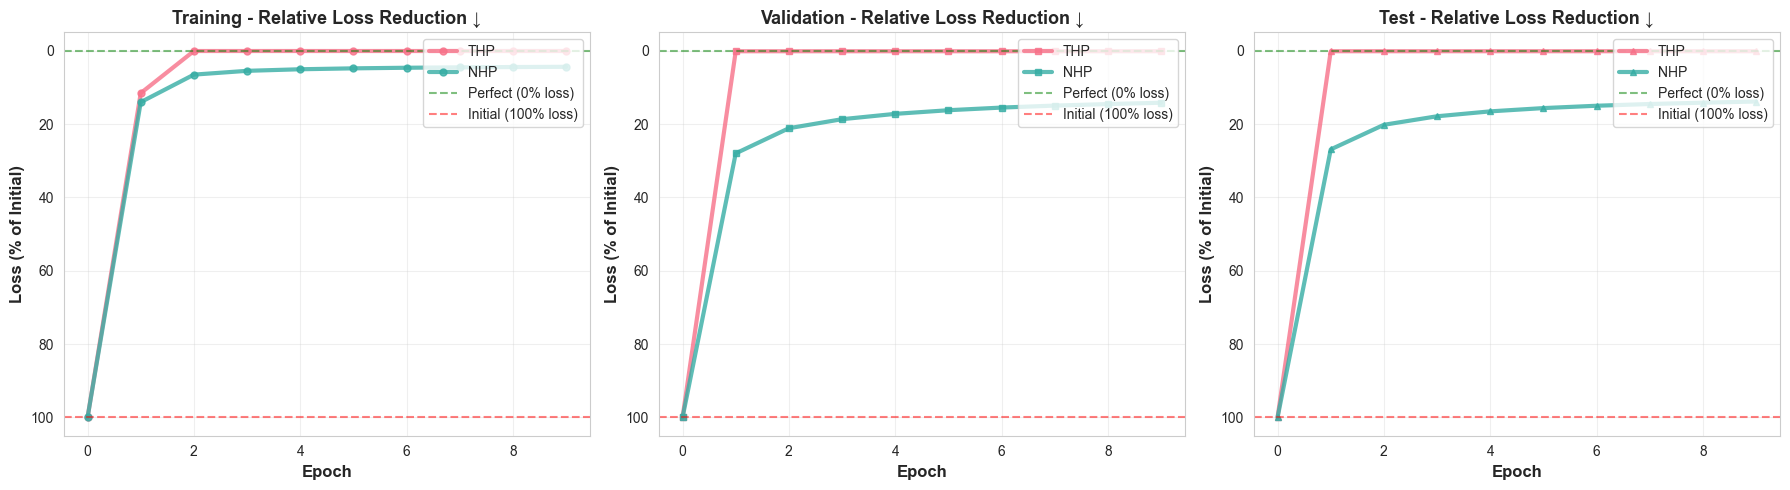


💡 Interpretation:
  - 100% = Initial loss (starting point)
  - 0% = Perfect (all loss eliminated)
  - Curves go DOWN as model learns ↓
  - Steeper downward curves = Faster learning
  - Compare which model reaches 50%, 25%, etc. first!


In [24]:
# Plot learning curves for StackOverflow dataset
if training_history:
    so_history = {k: v for k, v in training_history.items() if 'stackoverflow' in k}
    if so_history:
        print("📊 Learning Curves - STACKOVERFLOW Dataset\n")
        
        # Plot 1: Separate scales (each model has its own y-axis)
        print("=" * 60)
        print("Individual Model Curves (Separate Scales)")
        print("=" * 60)
        # plot_learning_curves(training_history, dataset_filter='stackoverflow')
        
        # Plot 2: Normalized comparison
        print("\n" + "=" * 60)
        print("Normalized Comparison (Relative Improvement)")
        print("=" * 60)
        plot_normalized_learning_curves(training_history, dataset_filter='stackoverflow')
    else:
        print("No StackOverflow training history yet. Train models on StackOverflow first (Cell 17).")
else:
    print("No training history available. Train models with the updated functions.")


📊 Complete Learning Curves Comparison
Plot saved to ./results/learning_curves_complete_comparison.png


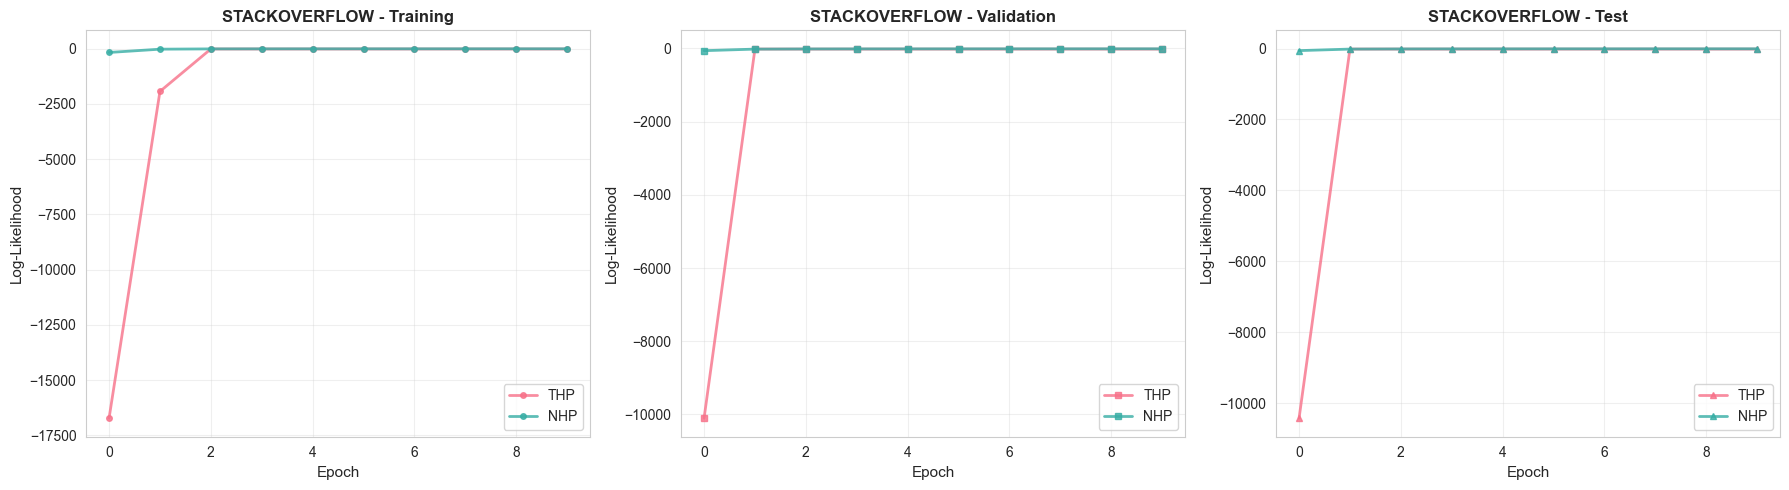


Convergence Analysis - Final Epoch Comparison

STACKOVERFLOW Dataset:
  1. NHP       : -8.2132
  2. THP       : -15.9424



In [25]:
def plot_all_learning_curves_comparison():
    """Plot learning curves comparing all models across all datasets."""
    if not training_history:
        print("No training history available.")
        return
    
    # Group by dataset
    datasets = {}
    for model_name, history in training_history.items():
        if '_' in model_name:
            dataset = model_name.split('_')[0]
            if dataset not in datasets:
                datasets[dataset] = {}
            datasets[dataset][model_name] = history
    
    if not datasets:
        print("No grouped dataset history found.")
        return
    
    n_datasets = len(datasets)
    fig, axes = plt.subplots(n_datasets, 3, figsize=(18, 5 * n_datasets))
    
    if n_datasets == 1:
        axes = axes.reshape(1, -1)
    
    for row, (dataset_name, models_history) in enumerate(datasets.items()):
        colors = sns.color_palette('husl', len(models_history))
        
        # Train plot
        ax_train = axes[row, 0]
        for idx, (model_name, history) in enumerate(models_history.items()):
            display_name = model_name.split('_')[-1]
            ax_train.plot(history['epochs'], history['train_loglike'],
                         label=display_name, linewidth=2, color=colors[idx],
                         marker='o', markersize=4, alpha=0.8)
        ax_train.set_xlabel('Epoch', fontsize=11)
        ax_train.set_ylabel('Log-Likelihood', fontsize=11)
        ax_train.set_title(f'{dataset_name.upper()} - Training', fontsize=12, fontweight='bold')
        ax_train.legend()
        ax_train.grid(True, alpha=0.3)
        
        # Valid plot
        ax_valid = axes[row, 1]
        for idx, (model_name, history) in enumerate(models_history.items()):
            display_name = model_name.split('_')[-1]
            ax_valid.plot(history['epochs'], history['valid_loglike'],
                         label=display_name, linewidth=2, color=colors[idx],
                         marker='s', markersize=4, alpha=0.8)
        ax_valid.set_xlabel('Epoch', fontsize=11)
        ax_valid.set_ylabel('Log-Likelihood', fontsize=11)
        ax_valid.set_title(f'{dataset_name.upper()} - Validation', fontsize=12, fontweight='bold')
        ax_valid.legend()
        ax_valid.grid(True, alpha=0.3)
        
        # Test plot
        ax_test = axes[row, 2]
        for idx, (model_name, history) in enumerate(models_history.items()):
            display_name = model_name.split('_')[-1]
            ax_test.plot(history['epochs'], history['test_loglike'],
                        label=display_name, linewidth=2, color=colors[idx],
                        marker='^', markersize=4, alpha=0.8)
        ax_test.set_xlabel('Epoch', fontsize=11)
        ax_test.set_ylabel('Log-Likelihood', fontsize=11)
        ax_test.set_title(f'{dataset_name.upper()} - Test', fontsize=12, fontweight='bold')
        ax_test.legend()
        ax_test.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/learning_curves_complete_comparison.png', 
                dpi=150, bbox_inches='tight')
    print(f"Plot saved to {RESULTS_DIR}/learning_curves_complete_comparison.png")
    plt.show()
    
    # Print convergence analysis
    print(f"\n{'='*70}")
    print("Convergence Analysis - Final Epoch Comparison")
    print(f"{'='*70}\n")
    
    for dataset_name, models_history in datasets.items():
        print(f"{dataset_name.upper()} Dataset:")
        final_scores = {}
        for model_name, history in models_history.items():
            display_name = model_name.split('_')[-1]
            final_scores[display_name] = history['test_loglike'][-1]
        
        # Sort by score
        sorted_models = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)
        for rank, (model, score) in enumerate(sorted_models, 1):
            print(f"  {rank}. {model:10s}: {score:7.4f}")
        print()

# Plot comprehensive comparison
if training_history:
    print("📊 Complete Learning Curves Comparison")
    plot_all_learning_curves_comparison()
else:
    print("No training history available.")


## 📊 Compare Results Across Datasets

Now you can compare how the same models perform on different datasets!


In [17]:
def compare_across_datasets(results_dict):
    """
    Compare model performance across multiple datasets.
    
    Args:
        results_dict: Dict with structure {dataset_name: {model_name: metrics}}
    """
    if not results_dict:
        print("No results to compare.")
        return
    
    print(f"\n{'='*70}")
    print("Cross-Dataset Model Comparison")
    print(f"{'='*70}\n")
    
    # Create a comprehensive table
    all_data = []
    for dataset, models in results_dict.items():
        for model, metrics in models.items():
            if metrics is not None:
                row = {'Dataset': dataset, 'Model': model}
                row.update(metrics)
                all_data.append(row)
    
    if not all_data:
        print("No valid results to display.")
        return
    
    df = pd.DataFrame(all_data)
    
    # Display table
    print(df.to_string(index=False))
    print(f"\n{'='*70}\n")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Loglikelihood by dataset and model
    if 'loglike' in df.columns:
        pivot_loglike = df.pivot(index='Model', columns='Dataset', values='loglike')
        pivot_loglike.plot(kind='bar', ax=axes[0], rot=45)
        axes[0].set_title('Log-Likelihood by Model & Dataset\n(Higher is Better)', 
                         fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Log-Likelihood')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(title='Dataset')
    
    # Plot 2: Best model per dataset
    if 'loglike' in df.columns:
        best_per_dataset = df.loc[df.groupby('Dataset')['loglike'].idxmax()]
        colors = sns.color_palette('viridis', len(best_per_dataset))
        axes[1].barh(best_per_dataset['Dataset'], best_per_dataset['loglike'], color=colors)
        axes[1].set_xlabel('Log-Likelihood')
        axes[1].set_title('Best Model Performance per Dataset', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='x')
        
        # Add model names as labels
        for i, (idx, row) in enumerate(best_per_dataset.iterrows()):
            axes[1].text(row['loglike'], i, f"  {row['Model']}", 
                        va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
    print(f"Plot saved to {RESULTS_DIR}/cross_dataset_comparison.png")
    plt.show()
    
    # Summary insights
    print("\n📊 Key Insights:")
    print("="*70)
    for dataset in df['Dataset'].unique():
        dataset_df = df[df['Dataset'] == dataset]
        if 'loglike' in dataset_df.columns:
            best_model = dataset_df.loc[dataset_df['loglike'].idxmax()]
            print(f"\n{dataset.upper()}:")
            print(f"  🏆 Best model: {best_model['Model']}")
            print(f"     Log-likelihood: {best_model['loglike']:.4f}")

# Show StackOverflow results summary
if 'stackoverflow_results' in dir() and stackoverflow_results:
    print("\n" + "="*70)
    print("📊 StackOverflow Model Comparison")
    print("="*70 + "\n")
    
    results_list = []
    for model, metrics in stackoverflow_results.items():
        if metrics:
            results_list.append({
                'Model': model,
                'Log-Likelihood': metrics.get('loglike', 'N/A'),
                'Num Events': int(metrics.get('num_events', 0))
            })
    
    df = pd.DataFrame(results_list)
    if 'Log-Likelihood' in df.columns:
        df = df.sort_values('Log-Likelihood', ascending=False)
    
    print(df.to_string(index=False))
    
    # Show winner
    if len(df) > 0 and df.iloc[0]['Log-Likelihood'] != 'N/A':
        best = df.iloc[0]
        print(f"\n🏆 BEST MODEL: {best['Model']}")
        print(f"   Log-Likelihood: {best['Log-Likelihood']:.4f}")
    
    print("\n" + "="*70)
else:
    print("No results. Run Cell 21 to train models first!")



📊 StackOverflow Model Comparison

Model  Log-Likelihood  Num Events
  THP       -15.94243       90512

🏆 BEST MODEL: THP
   Log-Likelihood: -15.9424

